In [1]:
invisible(source("/workspaces/estudo_de_adequabilidade_de_poder_de_teste/funcoes_final_nao_proporcionais.R"))


Attaching package: ‘survival’


The following object is masked from ‘package:Rlab’:

    cancer


Loading required package: ggpubr


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [9]:
### =========================================== APLICACAO ======================= ###
n <- 300
pi <- 0.5

# Ajuste para riscos não proporcionais
distribuicao <- "weibull"

# --- GRUPO EXPERIMENTAL (A) ---
shape_falha_experimental_weibull <- 0.5
parametro_falha_experimental <- 2.0 
parametro_censura_experimental <- 10000000
shape_censura_experimental_weibull <- shape_falha_experimental_weibull

# --- GRUPO CONTROLE (B) ---
shape_falha_controle_weibull <- 2.0
parametro_falha_controle <- 4.0
parametro_censura_controle <- 100000
shape_censura_controle_weibull <- shape_falha_controle_weibull

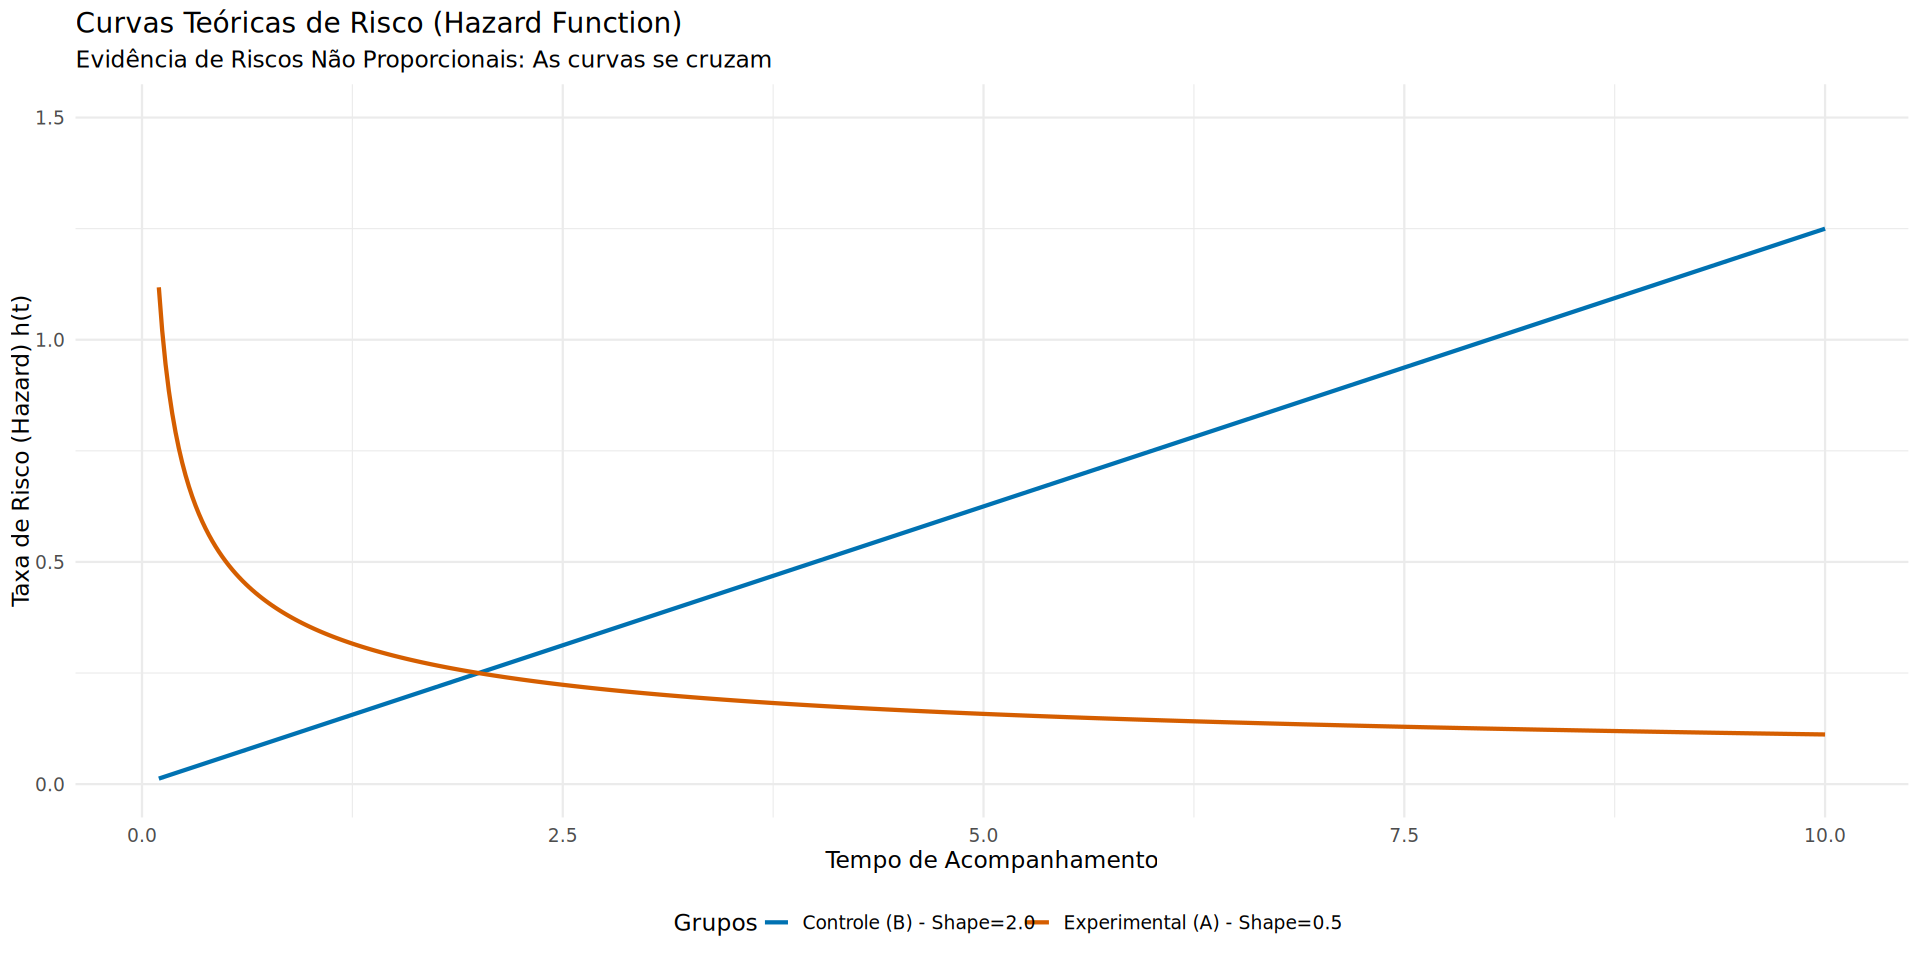

In [10]:
# Carregando o pacote necessário
library(ggplot2)

# --- 1. DEFINIÇÃO DOS PARÂMETROS ---
# Grupo Experimental (A)
shape_A <- shape_falha_experimental_weibull
scale_A <- parametro_falha_experimental   # Parâmetro de falha (escala)

# Grupo Controle (B)
shape_B <- shape_falha_controle_weibull
scale_B <- parametro_falha_controle   # Parâmetro de falha (escala)

# --- 2. FUNÇÃO TEÓRICA DE RISCO (HAZARD) WEIBULL ---
hazard_weibull <- function(t, shape, scale) {
  (shape / scale) * (t / scale)^(shape - 1)
}

# --- 3. GERAÇÃO DOS DADOS PARA O GRÁFICO ---
# Criamos uma sequência de tempo. Começamos de 0.1 (e não 0) porque, 
# quando shape < 1, o risco no instante t=0 tende ao infinito.
tempo <- seq(0.1, 10, length.out = 500)

risco_A <- hazard_weibull(tempo, shape_A, scale_A)
risco_B <- hazard_weibull(tempo, shape_B, scale_B)

# Montando o data.frame para o ggplot
df_risco <- data.frame(
  Tempo = rep(tempo, 2),
  Risco = c(risco_A, risco_B),
  Grupo = rep(c("Experimental (A) - Shape=0.5", "Controle (B) - Shape=2.0"), each = length(tempo))
)

# --- 4. PLOTANDO O GRÁFICO ---
grafico_riscos <- ggplot(df_risco, aes(x = Tempo, y = Risco, color = Grupo)) +
  geom_line(size = 1.2) +
  scale_color_manual(values = c("Experimental (A) - Shape=0.5" = "#D55E00", 
                                "Controle (B) - Shape=2.0" = "#0072B2")) +
  # Limitamos o eixo Y para focar na área de cruzamento das curvas
  coord_cartesian(ylim = c(0, 1.5)) +
  labs(
    title = "Curvas Teóricas de Risco (Hazard Function)",
    subtitle = "Evidência de Riscos Não Proporcionais: As curvas se cruzam",
    x = "Tempo de Acompanhamento",
    y = "Taxa de Risco (Hazard) h(t)",
    color = "Grupos"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "bottom")

# Exibir o gráfico
print(grafico_riscos)

In [7]:
dados <- exemplo(distribuicao, n, pi, 
                    parametro_falha_experimental, parametro_falha_controle, 
                    parametro_censura_experimental, parametro_censura_controle,
                    shape_falha_experimental_weibull, shape_censura_experimental_weibull, 
                    shape_falha_controle_weibull, shape_censura_controle_weibull, 
                    sdlog_falha_experimental, sdlog_censura_experimental, 
                    sdlog_falha_controle, sdlog_censura_controle)


=== Relatório da Simulação ===
Grupo Experimental (A) - Censura Observada: 0.0%
Grupo Controle     (B) - Censura Observada: 0.0%


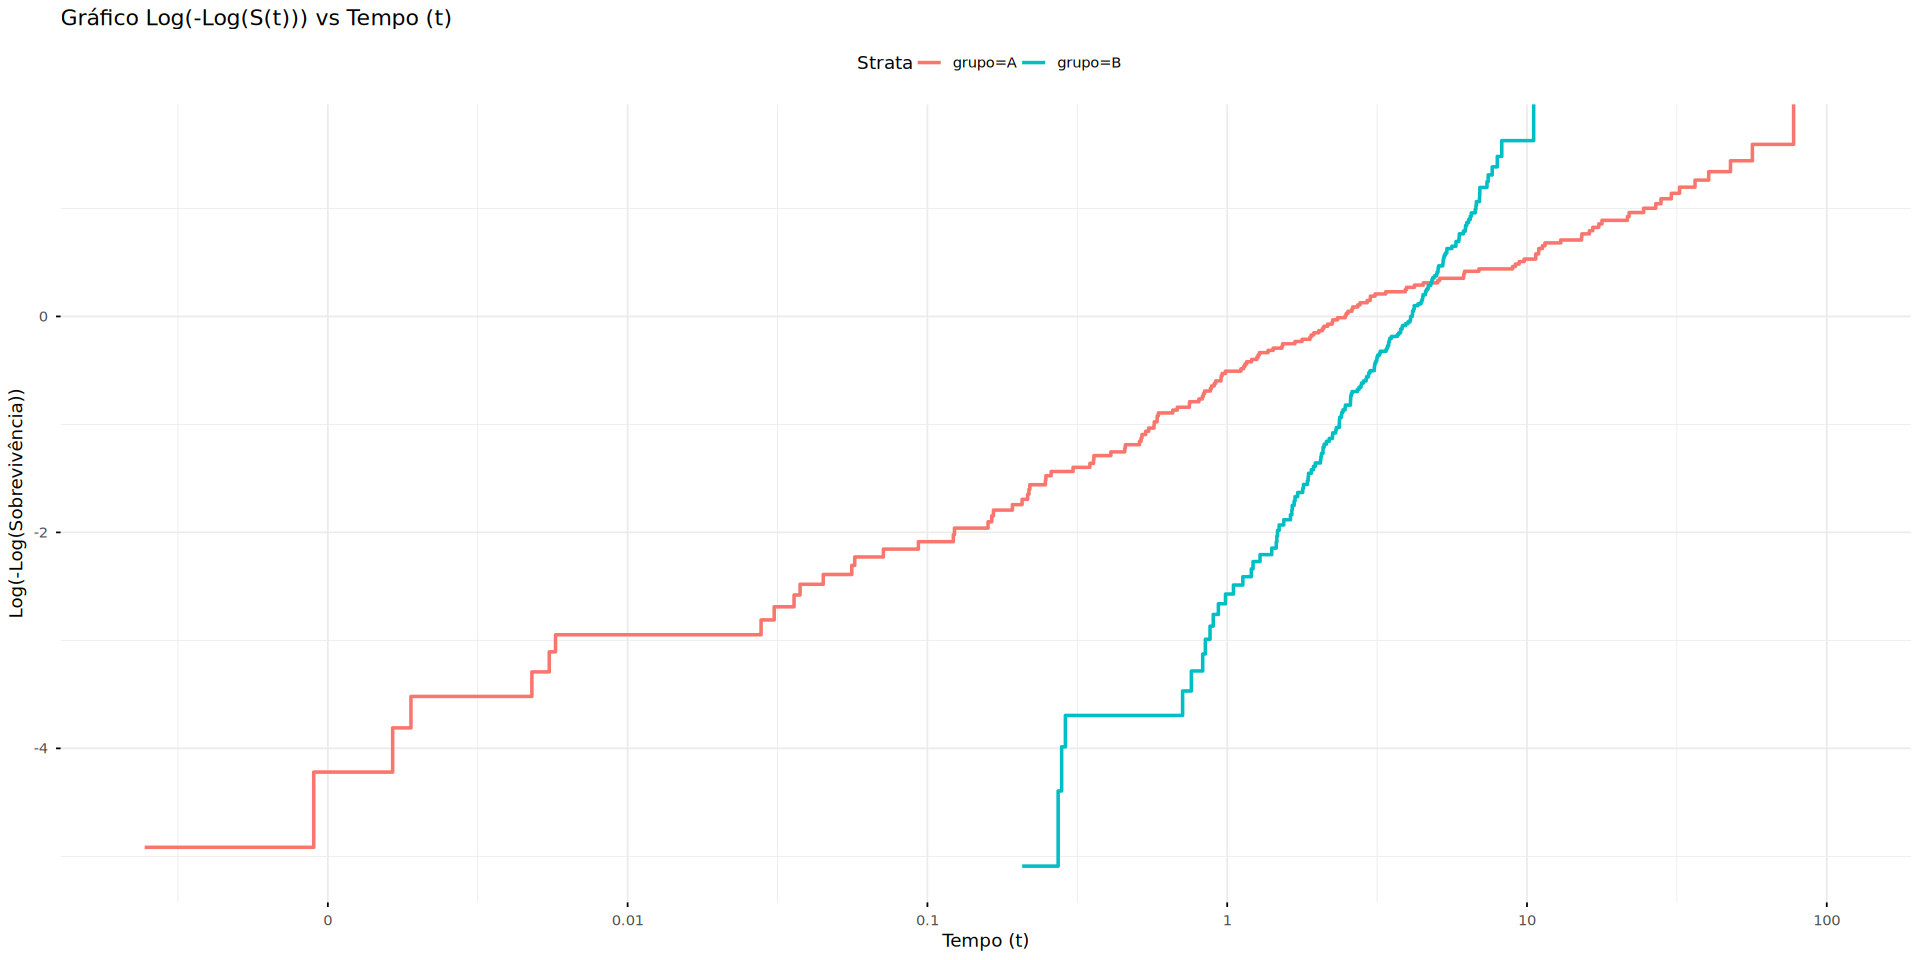

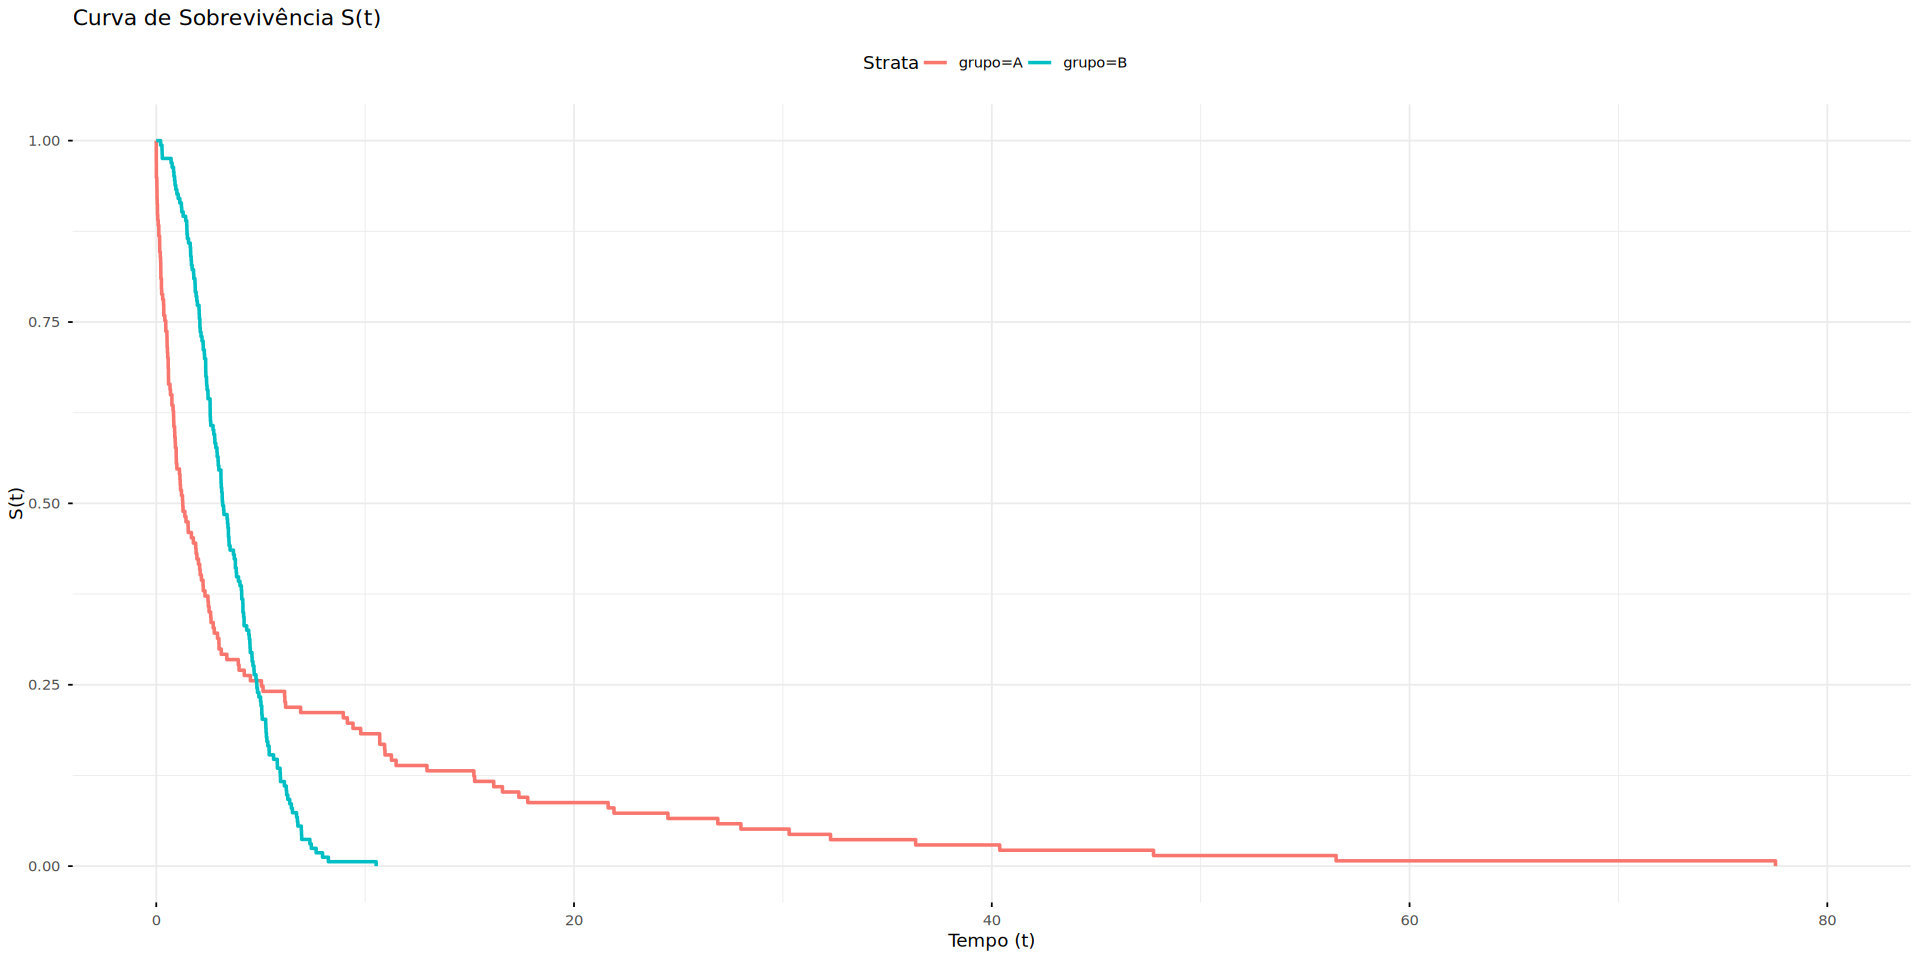

In [8]:
curva <- survfit(Surv(z, delta) ~ grupo, data = dados)
ggsurvplot(curva, 
           fun = "cloglog",   # Aplica log(-log(S(t))) no eixo Y
           # Não usamos nenhum argumento de log para o eixo X
           ggtheme = theme_minimal(),
           title = "Gráfico Log(-Log(S(t))) vs Tempo (t)",
           xlab = "Tempo (t)", 
           ylab = "Log(-Log(Sobrevivência))")

ggsurvplot(
  curva,
  conf.int = FALSE,
  risk.table = FALSE,
  ggtheme = theme_minimal(),
  title = "Curva de Sobrevivência S(t)",
  xlab = "Tempo (t)",
  ylab = "S(t)"
)$plot